In [10]:
import matplotlib 
import matplotlib.pyplot as plt
matplotlib.rc('xtick', labelsize=18) 
matplotlib.rc('ytick', labelsize=18) 
matplotlib.rc('font', **{'family': 'serif', 'serif': ['Computer Modern']})
matplotlib.rc('text', usetex=True)


In [11]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d


def add_mass_radius_from_pecaut(
    sample_sources_df,
    pecaut_path="./pecaut_mamjek.txt",
    parallax_col="parallax",
    gmag_col="phot_g_mean_mag_dr3",
    source_id_col="gaia_source_id",
):
    """
    Add absolute Gaia G magnitude, interpolated mass, and interpolated radius
    using the Pecaut & Mamajek table.

    Outputs:
        abs_G          : absolute Gaia G magnitude
        mass_interp    : mass in solar masses
        radius_interp  : radius in solar radii

    Uses fill_value=np.nan, so stars outside the table's M_G range
    are not extrapolated.
    """

    colnames = [
        "SpT", "Teff", "logT", "BCv", "logL", "Mbol", "R_Rsun", "Mv",
        "B-V", "Bt-Vt", "G-V", "Bp-Rp", "G-Rp", "M_G", "b-y", "U-B",
        "V-Rc", "V-Ic", "V-Ks", "J-H", "H-Ks", "M_J", "M_Ks", "Ks-W1",
        "W1-W2", "W1-W3", "W1-W4", "g-r", "i-z", "z-Y", "Msun", "SpT2"
    ]

    pecaut = pd.read_csv(
        pecaut_path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=colnames,
    )

    # Convert needed columns to numeric
    for col in ["M_G", "Msun", "R_Rsun"]:
        pecaut[col] = pd.to_numeric(pecaut[col], errors="coerce")

    # Keep only usable rows
    pecaut = pecaut.dropna(subset=["M_G", "Msun", "R_Rsun"])

    # Sort by absolute Gaia G magnitude
    pecaut = pecaut.sort_values("M_G")

    # Interpolation functions, no extrapolation
    mass_from_absG = interp1d(
        pecaut["M_G"],
        pecaut["Msun"],
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    radius_from_absG = interp1d(
        pecaut["M_G"],
        pecaut["R_Rsun"],
        kind="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    # Work on a copy so the original dataframe is not modified unexpectedly
    df = sample_sources_df.copy()

    # Ensure numeric input columns
    df[gmag_col] = pd.to_numeric(df[gmag_col], errors="coerce")
    df[parallax_col] = pd.to_numeric(df[parallax_col], errors="coerce")

    valid = (
        df[gmag_col].notna()
        & df[parallax_col].notna()
        & (df[parallax_col] > 0)
    )

    # Initialize outputs
    df["abs_G"] = np.nan
    df["mass_interp"] = np.nan
    df["radius_interp"] = np.nan

    # Absolute G magnitude
    df.loc[valid, "abs_G"] = (
        df.loc[valid, gmag_col]
        + 5 * np.log10(df.loc[valid, parallax_col] / 1000)
        + 5
    )

    # Interpolate mass and radius
    df.loc[valid, "mass_interp"] = mass_from_absG(df.loc[valid, "abs_G"])
    df.loc[valid, "radius_interp"] = radius_from_absG(df.loc[valid, "abs_G"])

    # Optional useful diagnostics
    print("Rows:", len(df))
    print("Valid parallax + G mag:", valid.sum())
    print("Mass NaN:", df["mass_interp"].isna().sum())
    print("Radius NaN:", df["radius_interp"].isna().sum())

    if source_id_col in df.columns:
        print(df[[source_id_col, "abs_G", "mass_interp", "radius_interp"]].head())
    else:
        print(df[["abs_G", "mass_interp", "radius_interp"]].head())

    return df

In [12]:
import pyarrow as pa
import pyarrow.ipc as ipc

with pa.memory_map("./will_simulated_stars/G23H_sample_subset.arrow", "r") as source:
    sample_sources = ipc.open_file(source).read_all()


sample_sources_df = sample_sources.to_pandas()

In [13]:
sample_sources_df

,gaia_source_id,source_id_dr2,hip_id,ra,dec,ra_error,dec_error,parallax,radial_velocity,pmra_hip,...,parallax_msms,parallax_error_msms,phot_g_mean_mag_msms,predicted_class_msms,q_binary_msms,ra_msms,radial_velocity_msms,radial_velocity_error_msms,astrometric_chi2_al_dr3,parallax_error
0,5479559378348931200,5479559378348931200,NaN,104.451569,-60.372920,0.017413,0.017271,9.163278,31.439222,NaN,...,9.163278,0.018659,14.707083,1.0,0.367839,104.451569,31.439222,5.467342,352.307739,0.018659
1,5481069145252396928,5481069145252396928,NaN,94.501858,-61.931762,0.019870,0.017888,10.807500,72.872055,NaN,...,10.807500,0.018703,14.926657,0.0,0.100000,94.501858,72.872055,4.053698,337.336060,0.018703
2,5481478983915584256,5481478983915584256,NaN,95.883588,-61.539116,0.099535,0.093117,12.664252,13.964805,NaN,...,12.664252,0.094480,12.735895,1.0,0.867628,95.883588,13.964805,1.014977,29628.988281,0.094480
3,5481618557469377408,5481618557469377408,NaN,97.669544,-60.554270,0.015607,0.015902,5.860141,26.489969,NaN,...,5.860141,0.015685,14.728782,1.0,0.614483,97.669544,26.489970,3.861051,324.326172,0.015685
4,5482185145257567232,5482185145257567232,NaN,93.728649,-60.655343,0.014073,0.013951,26.065368,24.997168,NaN,...,26.065368,0.014611,11.499378,1.0,0.630524,93.728649,24.997168,0.567186,727.135132,0.014611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10667,6880097807842527232,6880097807840983040,100027.0,304.412054,-12.508205,0.102068,0.064219,4.015717,-25.818953,22.125389,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31777.255859,0.107182
10668,6881507171289815808,6881507171289815808,NaN,314.966530,-19.270865,0.494852,0.328530,5.787716,-22.518469,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166320.093750,0.587363
10669,6891134705556330880,6891134705556330880,106147.0,322.516126,-12.511222,0.020525,0.016549,56.426457,-84.689545,1017.014771,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,825.463074,0.023555
10670,6905063765533078272,6905063765535544832,NaN,308.194628,-8.897616,0.062833,0.047892,10.033755,-32.714832,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1587.221924,0.069177


In [14]:
sample_sources_w_mass_radius_interpolation = add_mass_radius_from_pecaut(sample_sources_df)


print('')
print('stars with abs_G outside of Pecaut+Mamajek range')
# Rows where either mass or radius interpolation failed
nan_rows = sample_sources_w_mass_radius_interpolation[
    sample_sources_w_mass_radius_interpolation["mass_interp"].isna()
    | sample_sources_w_mass_radius_interpolation["radius_interp"].isna()
]


# Print the most relevant columns
cols_to_show = [
    "gaia_source_id",
    "phot_g_mean_mag_dr3",
    "parallax",
    "abs_G",
    "mass_interp",
    "radius_interp",
    'bb'
]


# Only keep columns that actually exist
cols_to_show = [c for c in cols_to_show if c in nan_rows.columns]

print(nan_rows[cols_to_show].to_string(index=False))

Rows: 10672
Valid parallax + G mag: 10672
Mass NaN: 5
Radius NaN: 5
        gaia_source_id      abs_G  mass_interp  radius_interp
0  5479559378348931200   9.517337     0.416070       0.431044
1  5481069145252396928  10.095283     0.364478       0.357631
2  5481478983915584256   8.248793     0.560486       0.574047
3  5481618557469377408   8.568322     0.526492       0.529479
4  5482185145257567232   8.579698     0.525295       0.528192

stars with abs_G outside of Pecaut+Mamajek range
     gaia_source_id  phot_g_mean_mag_dr3  parallax     abs_G  mass_interp  radius_interp
2026116260337482112             2.651682  8.981564 -2.581558          NaN            NaN
2610370969483589888             2.859529  8.936000 -2.384755          NaN            NaN
5713807856749312512             4.357016  7.213767 -1.352174          NaN            NaN
5778842011026728704             3.366725  5.250753 -3.032167          NaN            NaN
6880097807842527232             3.962830  4.015717 -3.018354     

In [15]:
# Keep only systems with valid interpolated mass AND radius
sample_sources_w_mass_radius = sample_sources_w_mass_radius_interpolation[
    sample_sources_w_mass_radius_interpolation["mass_interp"].notna()
    & sample_sources_w_mass_radius_interpolation["radius_interp"].notna()
].copy()

print("Original rows:", len(sample_sources_w_mass_radius_interpolation))
print("Clean rows:", len(sample_sources_w_mass_radius))
print("Removed rows:", len(sample_sources_w_mass_radius_interpolation) - len(sample_sources_w_mass_radius))

Original rows: 10672
Clean rows: 10667
Removed rows: 5


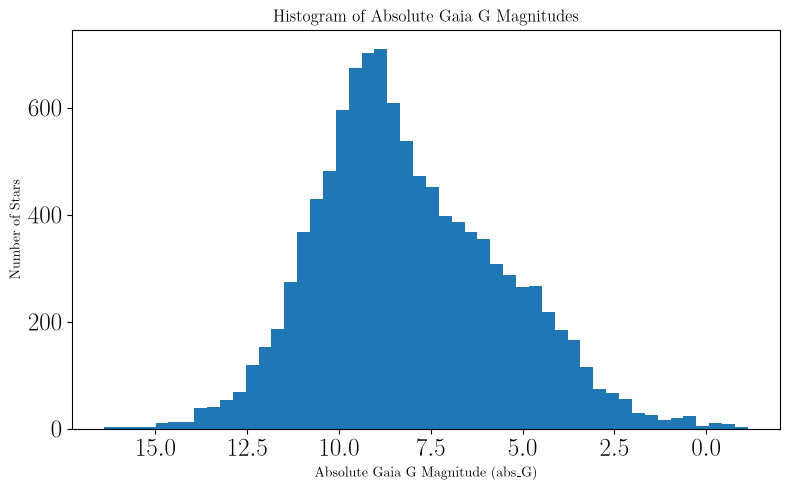

In [16]:
import matplotlib.pyplot as plt

# Keep only finite absolute magnitudes
abs_g = sample_sources_w_mass_radius["abs_G"]
abs_g = abs_g[np.isfinite(abs_g)]

# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(abs_g, bins=50)

plt.xlabel("Absolute Gaia G Magnitude (abs_G)")
plt.ylabel("Number of Stars")
plt.title("Histogram of Absolute Gaia G Magnitudes")

# Astronomers often invert magnitude axes
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

In [17]:
sample_sources_w_mass_radius.to_csv('./outputs/data/stars.csv', index=False)

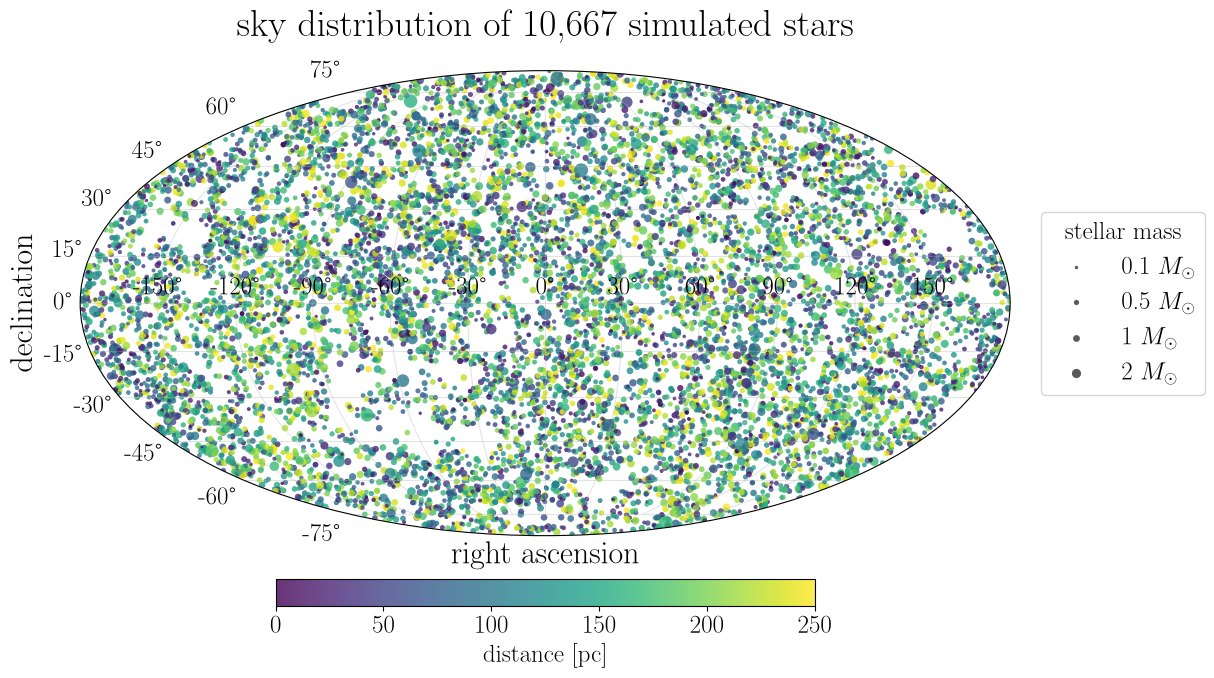

Saved outputs/figures/star_sky_distance.pdf


In [28]:
from pathlib import Path
from matplotlib.colors import Normalize

# Keep finite sky positions with positive parallaxes. Distance is in parsecs
# because parallax is stored in milliarcseconds.
sky = sample_sources_w_mass_radius.loc[
    np.isfinite(sample_sources_w_mass_radius["ra"])
    & np.isfinite(sample_sources_w_mass_radius["dec"])
    & np.isfinite(sample_sources_w_mass_radius["parallax"])
    & (sample_sources_w_mass_radius["parallax"] > 0)
    & np.isfinite(sample_sources_w_mass_radius["mass_interp"])
    & (sample_sources_w_mass_radius["mass_interp"] > 0)
].copy()
sky["distance_pc"] = 1000.0 / sky["parallax"]

# Wrap RA to [-pi, pi] and reverse it so RA increases toward the left,
# following the usual astronomical sky-map convention.
ra_rad = np.deg2rad(sky["ra"].to_numpy())
ra_wrapped = np.remainder(ra_rad + np.pi, 2.0 * np.pi) - np.pi
ra_plot = -ra_wrapped
dec_plot = np.deg2rad(sky["dec"].to_numpy())
distance_pc = sky["distance_pc"].to_numpy()
mass_msun = sky["mass_interp"].to_numpy()

# Matplotlib's `s` is marker area, so this makes displayed area scale
# linearly with stellar mass while retaining a small visible minimum.
def mass_to_marker_area(mass):
    return 4.0 + 20.0 * np.asarray(mass)

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection="mollweide")
points = ax.scatter(
    ra_plot,
    dec_plot,
    c=distance_pc,
    s=mass_to_marker_area(mass_msun),
    cmap="viridis",
    norm=Normalize(vmin=0.0, vmax=250.0),
    linewidths=0,
    alpha=0.8,
    rasterized=True,
)
ax.grid(True, alpha=0.35)
ax.set_xlabel("right ascension", fontsize=23)
ax.set_ylabel("declination", fontsize=23)
ax.set_title(
    rf"sky distribution of {len(sky):,} simulated stars",
    pad=25, fontsize=27
)

legend_masses = [0.1, 0.5, 1.0, 2.0]
legend_handles = [
    ax.scatter(
        [], [], s=mass_to_marker_area(mass), color="0.35",
        linewidths=0, label=rf"{mass:g} $M_\odot$",
    )
    for mass in legend_masses
]
ax.legend(
    handles=legend_handles, title="stellar mass", loc="center left",
    bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=18, title_fontsize=18,
)
colorbar = fig.colorbar(points, ax=ax, orientation="horizontal", pad=0.08, fraction=0.05)
colorbar.set_label("distance [pc]", fontsize=18)

figure_path = Path("outputs/figures/star_sky_distance.pdf")
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, bbox_inches="tight")
plt.show()
print(f"Saved {figure_path}")